# FluidWorld: Moving MNIST Training

First real training run of the PDE world model on Moving MNIST (10K sequences, 20 frames, 64x64).

Goal: check whether the PDE substrate can learn to predict digit motion.

Tracked metrics:
- Loss (reconstruction + prediction)
- Feature health (std, dead dims, effective rank)
- Inline viz: input / reconstruction / prediction / rollout
- SSIM, MSE on predictions

In [1]:
import sys, os, math, time
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# Project root
PROJECT = Path(r"C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld")
sys.path.insert(0, str(PROJECT))

from fluidworld.core.world_model_v2 import FluidWorldModelV2
from fluidworld.core.video_dataset import MovingMNISTDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti
VRAM: 12.9 GB


## 1. Configuration

Hyperparameters for training, scheduling, and the model. Kept in one place so sweeps are easy to re-run.

In [2]:
# === CONFIGURATION ===
DATA_PATH = str(PROJECT / "data" / "mnist_test_seq.npy")

# Training
EPOCHS = 100
BATCH_SIZE = 16
BPTT_STEPS = 4          # sequence = 5 frames (4 transitions)
LR = 3e-4
WEIGHT_DECAY = 0.04
MAX_BATCHES = 500        # batches per epoch (0 = full dataset)

# Cosine warm restarts
T_0_EPOCHS = 20          # first restart period (in epochs)
T_MULT = 2               # period multiplier after each restart
WARMUP_STEPS = 500       # linear warmup steps at start

# Scheduled sampling (teacher forcing -> self-prediction)
SS_START = 0.0           # initial self-prediction probability
SS_END = 0.5             # final self-prediction probability
SS_WARMUP_EPOCHS = 5     # keep full teacher forcing for first N epochs

# Resume from checkpoint (set to None to train from scratch)
RESUME_FROM = str(PROJECT / "checkpoints" / "moving_mnist" / "model_epoch_30.pt")

# Model
D_MODEL = 128
MAX_PDE_STEPS = 6
BELIEF_HW = 16

# Loss
RECON_WEIGHT = 1.0
PRED_WEIGHT = 1.0
VAR_WEIGHT = 0.1
VAR_TARGET = 0.3
EDGE_WEIGHT = 0.0        # Disabled — was 0.01, destabilized training
FREQ_WEIGHT = 0.0        # Disabled — was 0.005, not beneficial

# Visualization
VIZ_EVERY = 100          # show inline plots every N batches
ROLLOUT_STEPS = 10       # autoregressive rollout length

print(f"Data: {DATA_PATH}")
print(f"Epochs: {EPOCHS}, Batch: {BATCH_SIZE}, BPTT: {BPTT_STEPS}")
print(f"Model: d={D_MODEL}, PDE steps={MAX_PDE_STEPS}, belief={BELIEF_HW}x{BELIEF_HW}")
print(f"Scheduler: CosineWarmRestarts T_0={T_0_EPOCHS} epochs, T_mult={T_MULT}")
print(f"Scheduled sampling: p {SS_START} -> {SS_END} (warmup {SS_WARMUP_EPOCHS} epochs)")
print(f"Edge weight: {EDGE_WEIGHT}, Freq weight: {FREQ_WEIGHT}")
if RESUME_FROM:
    print(f"Resume from: {RESUME_FROM}")

Data: C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\data\mnist_test_seq.npy
Epochs: 100, Batch: 16, BPTT: 4
Model: d=128, PDE steps=6, belief=16x16
Scheduler: CosineWarmRestarts T_0=20 epochs, T_mult=2
Scheduled sampling: p 0.0 -> 0.5 (warmup 5 epochs)
Edge weight: 0.0, Freq weight: 0.0
Resume from: C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\checkpoints\moving_mnist\model_epoch_30.pt


## 2. Dataset

Loading raw Moving MNIST dataset into RAM: C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\data\mnist_test_seq.npy...
Moving MNIST ready: 160000 windows of 5 frames extracted.
Dataset: 160000 windows
Batches/epoch: 10000 (cap: 500)
Sample shape: torch.Size([5, 1, 64, 64]) (T, C, H, W), range: [0.00, 1.00]


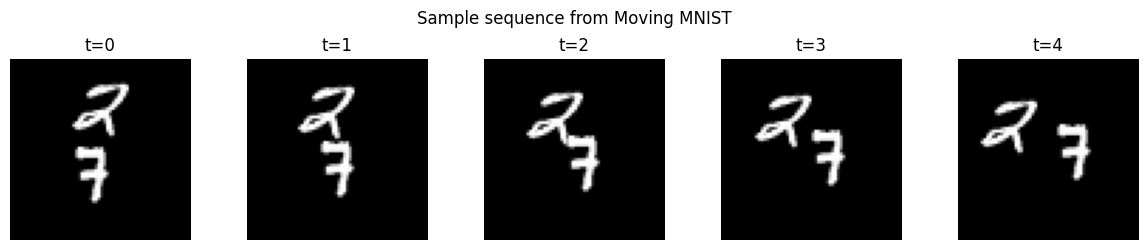

In [3]:
dataset = MovingMNISTDataset(npy_file=DATA_PATH, bptt_steps=BPTT_STEPS)

train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
)

print(f"Dataset: {len(dataset)} windows")
print(f"Batches/epoch: {len(train_loader)} (cap: {MAX_BATCHES if MAX_BATCHES else 'none'})")

# Preview
sample = dataset[0]
print(f"Sample shape: {sample.shape} (T, C, H, W), range: [{sample.min():.2f}, {sample.max():.2f}]")

fig, axes = plt.subplots(1, min(5, sample.shape[0]), figsize=(12, 2.5))
for t in range(min(5, sample.shape[0])):
    axes[t].imshow(sample[t, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[t].set_title(f"t={t}")
    axes[t].axis('off')
fig.suptitle("Sample sequence from Moving MNIST", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Model

In [4]:
model = FluidWorldModelV2(
    in_channels=1,
    d_model=D_MODEL,
    stimulus_dim=1,
    n_encoder_layers=3,
    max_steps_encoder=MAX_PDE_STEPS,
    belief_spatial_hw=BELIEF_HW,
    n_belief_evolve=3,
    recon_weight=RECON_WEIGHT,
    pred_weight=PRED_WEIGHT,
    loss_type="bce",
    var_weight=VAR_WEIGHT,
    var_target=VAR_TARGET,
    grad_weight=0.0,
    # Bio mechanisms
    use_fatigue=False,        # CRITICAL: fatigue causes collapse on MNIST
    use_inhibition=True,
    inhibition_strength=0.3,
    use_memory_pump=True,
    use_hebbian=True,
    hebbian_lr=0.01,
    hebbian_decay=0.99,
    use_deltanet=True,
    use_titans=True,
).to(device)

params = model.count_parameters()
print(f"Parameters: {params['total']:,} total ({params['trainable']:,} trainable)")
print(f"  Encoder: {params['encoder']:,}")
print(f"  BeliefField: {params['belief_field']:,}")
print(f"  Decoder: {params['decoder']:,}")
print(f"  Bio: {params['bio_mechanisms']:,}")

Parameters: 862,093 total (862,093 trainable)
  Encoder: 350,217
  BeliefField: 281,219
  Decoder: 230,657
  Bio: 0


## 4. Optimizer & Scheduler

In [5]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

batches_per_epoch = MAX_BATCHES if MAX_BATCHES else len(train_loader)

# Cosine annealing with warm restarts (per-step scheduling)
T_0_steps = T_0_EPOCHS * batches_per_epoch
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=T_0_steps, T_mult=T_MULT, eta_min=1e-6
)
scaler = GradScaler("cuda", enabled=(device.type == "cuda"))

# Resume from checkpoint
start_epoch = 1
global_step = 0
history = None

if RESUME_FROM and os.path.exists(RESUME_FROM):
    print(f"Loading checkpoint: {RESUME_FROM}")
    ckpt = torch.load(RESUME_FROM, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    # Re-create scheduler and advance it to the correct step
    # (old checkpoint used LambdaLR, so we just fast-forward the new scheduler)
    start_epoch = ckpt['epoch'] + 1
    global_step = ckpt['global_step']
    history = ckpt.get('history', None)
    # Fast-forward the new scheduler to match global_step
    for _ in range(global_step):
        scheduler.step()
    print(f"Resumed from epoch {ckpt['epoch']}, global_step {global_step}")
    print(f"LR after resume: {optimizer.param_groups[0]['lr']:.2e}")
    del ckpt
    torch.cuda.empty_cache()
else:
    print("Training from scratch")

print(f"T_0={T_0_steps} steps ({T_0_EPOCHS} epochs), T_mult={T_MULT}")
print(f"Warmup: {WARMUP_STEPS} steps")
print(f"LR: {LR} with cosine warm restarts")

Loading checkpoint: C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\checkpoints\moving_mnist\model_epoch_30.pt
Resumed from epoch 30, global_step 15000
LR after resume: 2.56e-04
T_0=10000 steps (20 epochs), T_mult=2
Warmup: 500 steps
LR: 0.0003 with cosine warm restarts


## 5. Visualization helpers

In [6]:
def compute_ssim_simple(pred, target):
    """Simplified SSIM between two (B,1,H,W) tensors."""
    C1, C2 = 0.01**2, 0.03**2
    mu_p = F.avg_pool2d(pred, 3, 1, 1)
    mu_t = F.avg_pool2d(target, 3, 1, 1)
    sigma_p = F.avg_pool2d(pred**2, 3, 1, 1) - mu_p**2
    sigma_t = F.avg_pool2d(target**2, 3, 1, 1) - mu_t**2
    sigma_pt = F.avg_pool2d(pred * target, 3, 1, 1) - mu_p * mu_t
    ssim = ((2*mu_p*mu_t + C1) * (2*sigma_pt + C2)) / \
           ((mu_p**2 + mu_t**2 + C1) * (sigma_p + sigma_t + C2))
    return ssim.mean().item()


def show_predictions(model, batch, epoch, step, loss_val):
    """Show input / reconstruction / prediction / GT side by side."""
    model.eval()
    with torch.no_grad():
        vb = batch[:6].to(device)  # 6 samples
        B_viz = vb.shape[0]
        stim = torch.zeros(B_viz, 1, device=device)
        
        # Encode frame 0
        enc = model.encode(vb[:, 0])
        recon = model.decode_to_pixels(enc["features"])
        
        # Predict frame 1
        state = model.belief_field.init_state(B_viz, device, vb.dtype)
        state = model.belief_field.write(state, enc["features"])
        state = model.belief_field.evolve(state, stimulus=stim)
        z_pred = model.belief_field.read_spatial(
            state, (enc["features"].shape[2], enc["features"].shape[3]))
        pred_next = model.decode_to_pixels(z_pred)
        
        # Compute metrics
        mse_recon = F.mse_loss(recon, vb[:, 0]).item()
        mse_pred = F.mse_loss(pred_next, vb[:, 1]).item()
        ssim_recon = compute_ssim_simple(recon, vb[:, 0])
        ssim_pred = compute_ssim_simple(pred_next, vb[:, 1])
    
    # Plot
    fig, axes = plt.subplots(4, 6, figsize=(14, 9))
    row_labels = ['Input (t=0)', 'Reconstruction', 'GT (t=1)', 'Predicted (t=1)']
    imgs = [
        vb[:, 0].cpu(),
        recon.cpu(),
        vb[:, 1].cpu(),
        pred_next.cpu(),
    ]
    for r in range(4):
        for c in range(6):
            axes[r, c].imshow(imgs[r][c, 0].numpy(), cmap='gray', vmin=0, vmax=1)
            axes[r, c].axis('off')
        axes[r, 0].set_ylabel(row_labels[r], fontsize=10, rotation=0, labelpad=80, va='center')
    
    fig.suptitle(
        f"Epoch {epoch} | Step {step} | Loss={loss_val:.4f}\n"
        f"Recon MSE={mse_recon:.4f} SSIM={ssim_recon:.3f} | "
        f"Pred MSE={mse_pred:.4f} SSIM={ssim_pred:.3f}",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()
    model.train()
    return mse_recon, mse_pred, ssim_recon, ssim_pred


def show_rollout(model, batch, n_steps=10):
    """Show autoregressive rollout vs ground truth."""
    model.eval()
    with torch.no_grad():
        vb = batch[:4].to(device)
        B_viz = vb.shape[0]
        stim = torch.zeros(B_viz, 1, device=device)
        
        rollout = model.rollout(vb[:, 0], stim, n_steps=n_steps)
    
    n_show = min(n_steps, vb.shape[1] - 1)  # GT frames available
    fig, axes = plt.subplots(3, n_show + 1, figsize=(2.5 * (n_show + 1), 7))
    
    sample_idx = 0
    
    # Row 0: Ground truth
    for t in range(n_show + 1):
        if t < vb.shape[1]:
            axes[0, t].imshow(vb[sample_idx, t, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[0, t].set_title(f"t={t}", fontsize=9)
        axes[0, t].axis('off')
    axes[0, 0].set_ylabel('Ground Truth', fontsize=10, rotation=0, labelpad=70, va='center')
    
    # Row 1: Rollout predictions
    axes[1, 0].imshow(vb[sample_idx, 0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1, 0].set_title('seed', fontsize=9)
    axes[1, 0].axis('off')
    for t in range(n_show):
        axes[1, t + 1].imshow(rollout[sample_idx, t, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[1, t + 1].axis('off')
    axes[1, 0].set_ylabel('Rollout', fontsize=10, rotation=0, labelpad=70, va='center')
    
    # Row 2: Difference (abs error)
    axes[2, 0].axis('off')
    for t in range(n_show):
        if t + 1 < vb.shape[1]:
            diff = (rollout[sample_idx, t, 0].cpu() - vb[sample_idx, t + 1, 0].cpu()).abs()
            axes[2, t + 1].imshow(diff.numpy(), cmap='hot', vmin=0, vmax=0.5)
        axes[2, t + 1].axis('off')
    axes[2, 0].set_ylabel('|Error|', fontsize=10, rotation=0, labelpad=70, va='center')
    
    # Compute per-step SSIM
    ssim_per_step = []
    for t in range(n_show):
        if t + 1 < vb.shape[1]:
            s = compute_ssim_simple(
                rollout[:, t].to(device),
                vb[:, t + 1].to(device)
            )
            ssim_per_step.append(s)
    
    ssim_str = ', '.join([f'{s:.3f}' for s in ssim_per_step])
    fig.suptitle(f"Autoregressive Rollout ({n_steps} steps)\nSSIM per step: [{ssim_str}]", fontsize=12)
    plt.tight_layout()
    plt.show()
    model.train()
    return ssim_per_step


def show_training_curves(history):
    """Plot training curves from history dict."""
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    
    # Loss
    axes[0, 0].plot(history['step'], history['total_loss'], alpha=0.3, color='blue')
    # Running average
    if len(history['total_loss']) > 20:
        window = min(50, len(history['total_loss']) // 4)
        avg = np.convolve(history['total_loss'], np.ones(window)/window, mode='valid')
        axes[0, 0].plot(history['step'][window-1:], avg, color='blue', linewidth=2)
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].set_xlabel('Step')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Recon vs Pred
    axes[0, 1].plot(history['step'], history['recon_loss'], alpha=0.3, color='green', label='Recon')
    axes[0, 1].plot(history['step'], history['pred_loss'], alpha=0.3, color='red', label='Pred')
    if len(history['recon_loss']) > 20:
        window = min(50, len(history['recon_loss']) // 4)
        avg_r = np.convolve(history['recon_loss'], np.ones(window)/window, mode='valid')
        avg_p = np.convolve(history['pred_loss'], np.ones(window)/window, mode='valid')
        axes[0, 1].plot(history['step'][window-1:], avg_r, color='green', linewidth=2)
        axes[0, 1].plot(history['step'][window-1:], avg_p, color='red', linewidth=2)
    axes[0, 1].legend()
    axes[0, 1].set_title('Recon vs Pred Loss')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Feature std
    axes[0, 2].plot(history['step'], history['feature_std'], alpha=0.5, color='purple')
    axes[0, 2].axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='collapse threshold')
    axes[0, 2].set_title('Feature Std')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # LR
    axes[1, 0].plot(history['step'], history['lr'], color='orange')
    axes[1, 0].set_title('Learning Rate')
    axes[1, 0].grid(True, alpha=0.3)
    
    # SSIM (if available)
    if history['ssim_recon']:
        viz_steps = history['viz_step']
        axes[1, 1].plot(viz_steps, history['ssim_recon'], 'g-o', markersize=3, label='Recon')
        axes[1, 1].plot(viz_steps, history['ssim_pred'], 'r-o', markersize=3, label='Pred')
        axes[1, 1].set_ylim(0, 1)
        axes[1, 1].legend()
        axes[1, 1].set_title('SSIM')
        axes[1, 1].grid(True, alpha=0.3)
    
    # PDE energy
    if history['step_energy']:
        axes[1, 2].plot(history['step'], history['step_energy'], alpha=0.3, color='teal')
        if len(history['step_energy']) > 20:
            window = min(50, len(history['step_energy']) // 4)
            avg_e = np.convolve(history['step_energy'], np.ones(window)/window, mode='valid')
            axes[1, 2].plot(history['step'][window-1:], avg_e, color='teal', linewidth=2)
        axes[1, 2].set_title('PDE Step Energy')
        axes[1, 2].grid(True, alpha=0.3)
    
    # Edge + Freq losses
    if history.get('edge_loss'):
        axes[1, 3].plot(history['step'][-len(history['edge_loss']):], history['edge_loss'], alpha=0.3, color='darkorange', label='Edge')
        axes[1, 3].plot(history['step'][-len(history['freq_loss']):], history['freq_loss'], alpha=0.3, color='darkviolet', label='Freq')
        if len(history['edge_loss']) > 20:
            window = min(50, len(history['edge_loss']) // 4)
            avg_e = np.convolve(history['edge_loss'], np.ones(window)/window, mode='valid')
            avg_f = np.convolve(history['freq_loss'], np.ones(window)/window, mode='valid')
            step_slice = history['step'][-len(history['edge_loss']):]
            axes[1, 3].plot(step_slice[window-1:], avg_e, color='darkorange', linewidth=2)
            axes[1, 3].plot(step_slice[window-1:], avg_f, color='darkviolet', linewidth=2)
        axes[1, 3].legend()
        axes[1, 3].set_title('Edge & Freq Loss')
        axes[1, 3].grid(True, alpha=0.3)
    
    fig.suptitle('Training Curves', fontsize=14)
    plt.tight_layout()
    plt.show()

print("Visualization helpers ready.")

Visualization helpers ready.


Auxiliary losses for sharper predictions. `edge_loss` uses Sobel filters to penalize blurred contours, `freq_loss` compares FFT magnitudes. Without these, digits tend to melt into grey blobs.

In [7]:
# === Edge & Frequency Loss Functions ===

def edge_loss(pred, target):
    """Sobel edge loss - forces the model to preserve contours (holes in digits like 8, 9, 0)."""
    sobel_x = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], device=pred.device, dtype=pred.dtype).view(1,1,3,3)
    sobel_y = sobel_x.transpose(2,3)
    # Handle multi-channel by applying per-channel
    B, C, H, W = pred.shape
    pred_flat = pred.reshape(B*C, 1, H, W)
    target_flat = target.reshape(B*C, 1, H, W)
    edges_pred = torch.abs(F.conv2d(pred_flat, sobel_x, padding=1)) + torch.abs(F.conv2d(pred_flat, sobel_y, padding=1))
    edges_target = torch.abs(F.conv2d(target_flat, sobel_x, padding=1)) + torch.abs(F.conv2d(target_flat, sobel_y, padding=1))
    return F.mse_loss(edges_pred, edges_target)

def freq_loss(pred, target):
    """FFT frequency loss - penalizes loss of high-frequency details."""
    fft_pred = torch.fft.rfft2(pred)
    fft_target = torch.fft.rfft2(target)
    return F.mse_loss(torch.abs(fft_pred), torch.abs(fft_target))

print("Edge loss and frequency loss functions defined.")

Edge loss and frequency loss functions defined.


## 6. Training loop

Starting training: epochs 31-100 x 500 batches
Visualization every 100 batches
Checkpoints: C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\checkpoints\moving_mnist
Edge weight: 0.0, Freq weight: 0.0
Scheduled sampling prob: 0.137


C:\Users\infinition\AppData\Local\Temp\ipykernel_29136\2289111149.py:17: UserWarning: ComplexHalf support is experimental and many operators don't support it yet. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\EmptyTensor.cpp:55.)
  fft_pred = torch.fft.rfft2(pred)


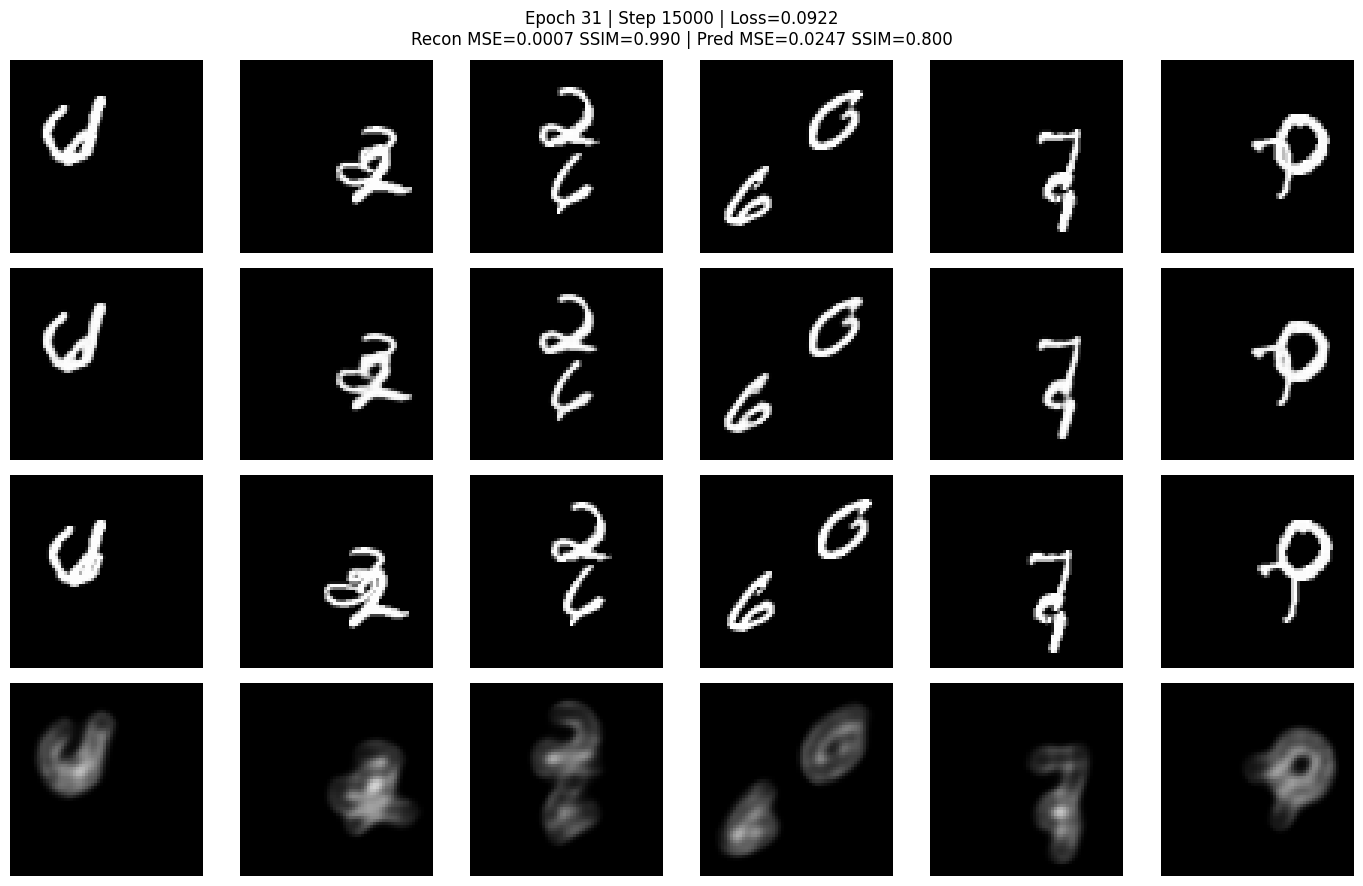

  E31 [50/500] Loss=0.1512 Recon=0.0567 Pred=0.0934 Edge=1.0306 Freq=73.9801 Std=0.208 SS=0.14 LR=2.55e-04 | 1.1 it/s ETA 533min


KeyboardInterrupt: 

In [8]:
# Training history
if history is None:
    history = {
        'step': [], 'total_loss': [], 'recon_loss': [], 'pred_loss': [],
        'edge_loss': [], 'freq_loss': [],
        'feature_std': [], 'lr': [], 'step_energy': [],
        'viz_step': [], 'ssim_recon': [], 'ssim_pred': [],
        'mse_recon': [], 'mse_pred': [],
    }
else:
    # Ensure new keys exist for resumed training
    if 'edge_loss' not in history:
        history['edge_loss'] = []
    if 'freq_loss' not in history:
        history['freq_loss'] = []

# Keep a reference batch for consistent visualization
viz_batch = None
use_amp = device.type == "cuda"

# Checkpoint directory
ckpt_dir = PROJECT / "checkpoints" / "moving_mnist"
ckpt_dir.mkdir(parents=True, exist_ok=True)

print(f"Starting training: epochs {start_epoch}-{EPOCHS} x {batches_per_epoch} batches")
print(f"Visualization every {VIZ_EVERY} batches")
print(f"Checkpoints: {ckpt_dir}")
print(f"Edge weight: {EDGE_WEIGHT}, Freq weight: {FREQ_WEIGHT}")
print("="*60)

model.train()
t_start = time.time()

for epoch in range(start_epoch, EPOCHS + 1):
    epoch_loss = 0.0
    epoch_recon = 0.0
    epoch_pred = 0.0
    epoch_edge = 0.0
    epoch_freq = 0.0
    batch_count = 0
    max_batches = MAX_BATCHES if MAX_BATCHES else len(train_loader)

    # Scheduled sampling probability for this epoch
    if epoch <= SS_WARMUP_EPOCHS:
        ss_prob = SS_START
    else:
        progress = (epoch - SS_WARMUP_EPOCHS) / max(EPOCHS - SS_WARMUP_EPOCHS, 1)
        ss_prob = SS_START + (SS_END - SS_START) * progress
    ss_prob = min(ss_prob, SS_END)

    if epoch == start_epoch or epoch % 5 == 0:
        print(f"Scheduled sampling prob: {ss_prob:.3f}")

    for images in train_loader:
        if batch_count >= max_batches:
            break
        batch_count += 1

        images = images.to(device, non_blocking=True)
        B, T_total, C, H, W = images.shape

        # Keep first batch for viz
        if viz_batch is None:
            viz_batch = images[:8].clone()

        stim_t = torch.zeros(B, 1, device=device)
        optimizer.zero_grad()

        batch_total = 0.0
        batch_recon = 0.0
        batch_pred = 0.0
        batch_edge = 0.0
        batch_freq = 0.0
        batch_energy = 0.0
        current_state = None
        n_steps = T_total - 1
        prev_pred = None  # for scheduled sampling

        for t in range(n_steps):
            x_gt = images[:, t]
            x_next = images[:, t + 1]

            # Scheduled sampling: decide whether to use model's prediction
            if t > 0 and prev_pred is not None and ss_prob > 0:
                use_pred = torch.rand(1).item() < ss_prob
                x_current = prev_pred.detach() if use_pred else x_gt
            else:
                x_current = x_gt

            with autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
                out = model(
                    x_current=x_current,
                    stimulus=stim_t,
                    x_next=x_next,
                    current_state=current_state,
                )
                step_loss = out["loss"] / n_steps

                # Edge + Freq losses for sharper outputs
                x_recon_live = out["x_recon_live"]
                x_pred_live = out["x_pred_live"]
                loss_edge = (edge_loss(x_recon_live, x_current) + edge_loss(x_pred_live, x_next)) / n_steps
                loss_freq = (freq_loss(x_recon_live, x_current) + freq_loss(x_pred_live, x_next)) / n_steps
                step_loss = step_loss + EDGE_WEIGHT * loss_edge + FREQ_WEIGHT * loss_freq

            scaler.scale(step_loss).backward()

            batch_total += step_loss.item()
            batch_recon += out["recon_loss"].item() / n_steps
            batch_pred += out["pred_loss"].item() / n_steps
            batch_edge += loss_edge.item()
            batch_freq += loss_freq.item()
            batch_energy += out.get("mean_step_energy", 0.0) / n_steps
            current_state = out["next_state"]
            # Store prediction for scheduled sampling
            prev_pred = out.get("x_pred", None)

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        # LR scheduling: warmup then cosine warm restarts
        if global_step < WARMUP_STEPS:
            warmup_lr = LR * (global_step + 1) / WARMUP_STEPS
            for pg in optimizer.param_groups:
                pg['lr'] = warmup_lr
        else:
            scheduler.step()

        # Feature monitoring
        with torch.no_grad():
            sample_features = model.encode(images[:, 0])["features"]
            feature_std = sample_features.std(dim=0).mean().item()

        # Record history
        history['step'].append(global_step)
        history['total_loss'].append(batch_total)
        history['recon_loss'].append(batch_recon)
        history['pred_loss'].append(batch_pred)
        history['edge_loss'].append(batch_edge)
        history['freq_loss'].append(batch_freq)
        history['feature_std'].append(feature_std)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        history['step_energy'].append(batch_energy)

        epoch_loss += batch_total
        epoch_recon += batch_recon
        epoch_pred += batch_pred
        epoch_edge += batch_edge
        epoch_freq += batch_freq

        # Inline visualization
        if global_step % VIZ_EVERY == 0 and global_step > 0 and viz_batch is not None:
            mse_r, mse_p, ssim_r, ssim_p = show_predictions(
                model, viz_batch, epoch, global_step, batch_total)
            history['viz_step'].append(global_step)
            history['ssim_recon'].append(ssim_r)
            history['ssim_pred'].append(ssim_p)
            history['mse_recon'].append(mse_r)
            history['mse_pred'].append(mse_p)

        # Progress
        if batch_count % 50 == 0:
            total_steps = EPOCHS * batches_per_epoch
            elapsed = time.time() - t_start
            steps_since_start = max(global_step - (start_epoch - 1) * batches_per_epoch, 1)
            steps_per_sec = steps_since_start / max(elapsed, 1)
            remaining = (total_steps - global_step) / max(steps_per_sec, 0.01)
            print(
                f"  E{epoch} [{batch_count}/{max_batches}] "
                f"Loss={batch_total:.4f} Recon={batch_recon:.4f} Pred={batch_pred:.4f} "
                f"Edge={batch_edge:.4f} Freq={batch_freq:.4f} "
                f"Std={feature_std:.3f} SS={ss_prob:.2f} "
                f"LR={optimizer.param_groups[0]['lr']:.2e} "
                f"| {steps_per_sec:.1f} it/s ETA {remaining/60:.0f}min"
            )

        global_step += 1

    # End of epoch summary
    n = max(batch_count, 1)
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{EPOCHS} complete")
    print(f"  Avg Loss={epoch_loss/n:.4f}  Recon={epoch_recon/n:.4f}  Pred={epoch_pred/n:.4f}")
    print(f"  Avg Edge={epoch_edge/n:.4f}  Freq={epoch_freq/n:.4f}")
    print(f"  Feature Std={feature_std:.4f} {'OK' if feature_std > 0.1 else 'WARNING: LOW!'}")
    print(f"  SS prob={ss_prob:.3f}  LR={optimizer.param_groups[0]['lr']:.2e}")
    print(f"{'='*60}\n")

    # Epoch checkpoint
    torch.save({
        'epoch': epoch,
        'global_step': global_step,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'history': history,
        'ss_prob': ss_prob,
    }, ckpt_dir / f"model_epoch_{epoch}.pt")

elapsed_total = time.time() - t_start
history['elapsed_total_sec'] = elapsed_total
print(f"\nTraining complete in {elapsed_total/60:.1f} minutes ({elapsed_total/3600:.1f} hours)")
print(f"Final loss: {history['total_loss'][-1]:.4f}")

## 7. Training curves

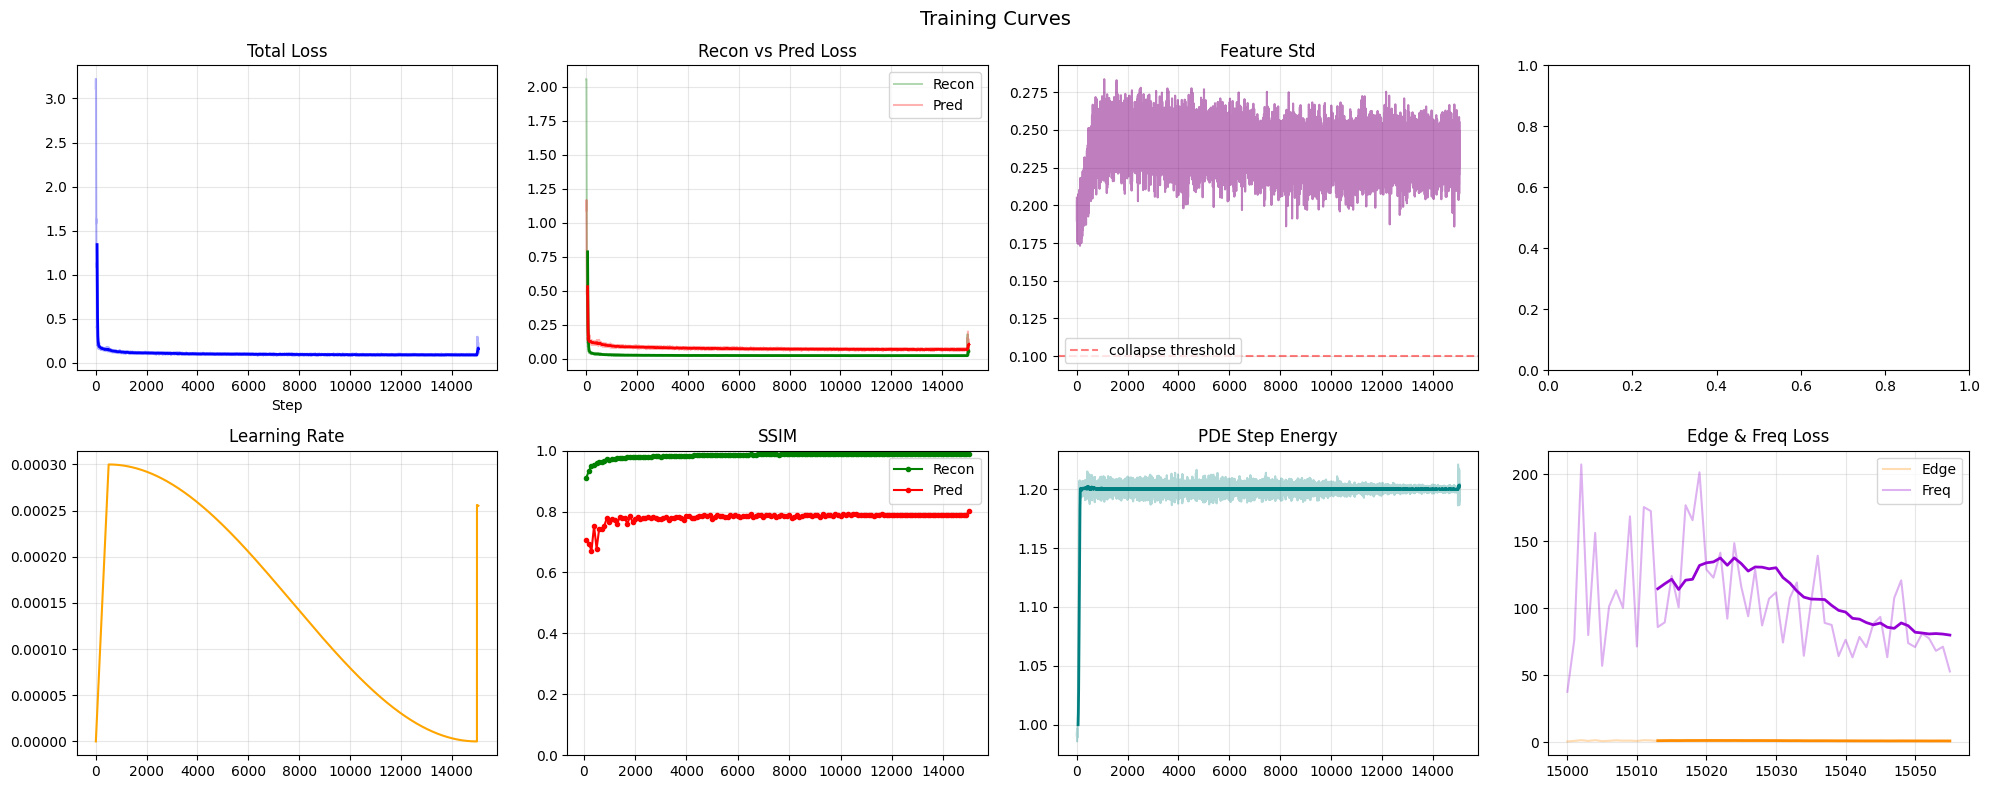

In [9]:
show_training_curves(history)

## 8. Final prediction quality

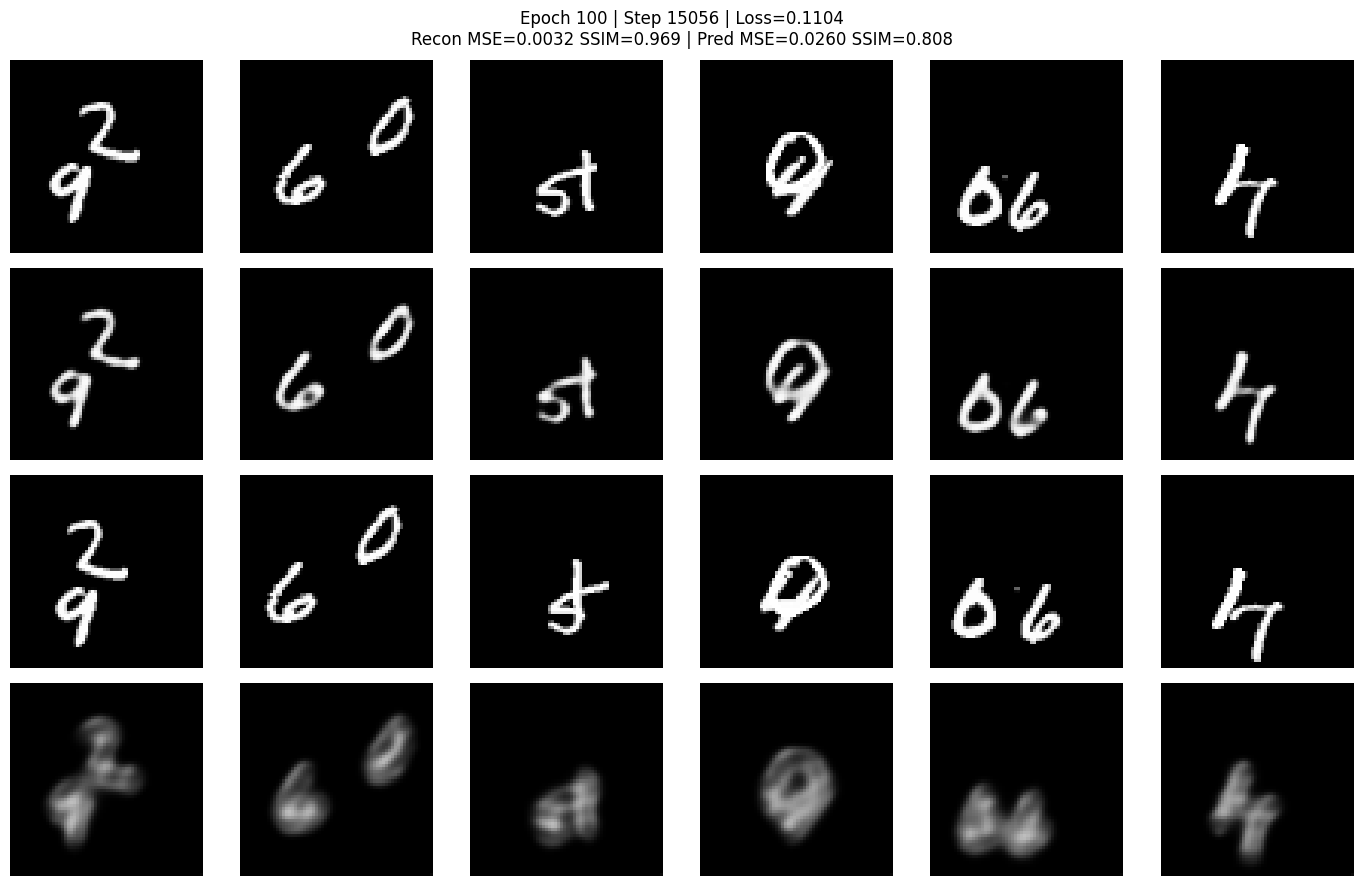

(0.0032236166298389435,
 0.026034384965896606,
 0.9687145948410034,
 0.8081459999084473)

In [10]:
# Show predictions on fresh samples (not the viz_batch used during training)
fresh_batch = next(iter(train_loader))[:8]
show_predictions(model, fresh_batch, EPOCHS, global_step, history['total_loss'][-1])

## 9. Autoregressive rollout

Rollout: 10 frames from seed frame
(GT disponible seulement pour les {BPTT_STEPS} premiers)
Loading raw Moving MNIST dataset into RAM: C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\data\mnist_test_seq.npy...
Moving MNIST ready: 100000 windows of 11 frames extracted.


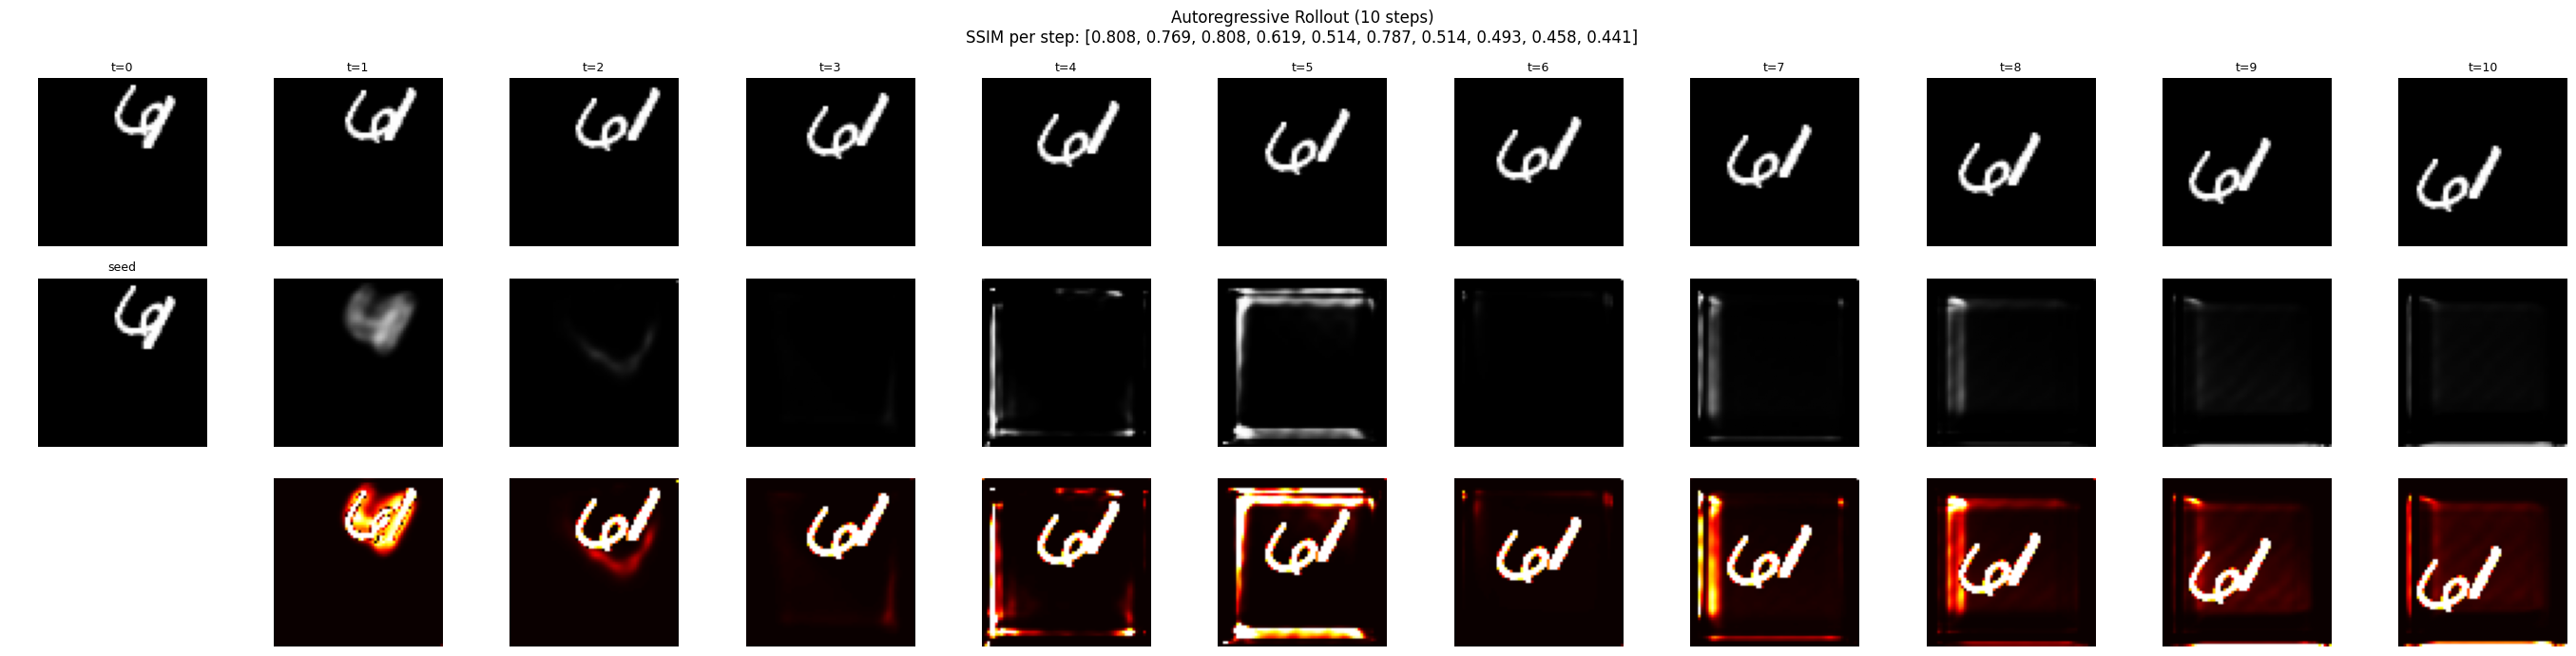

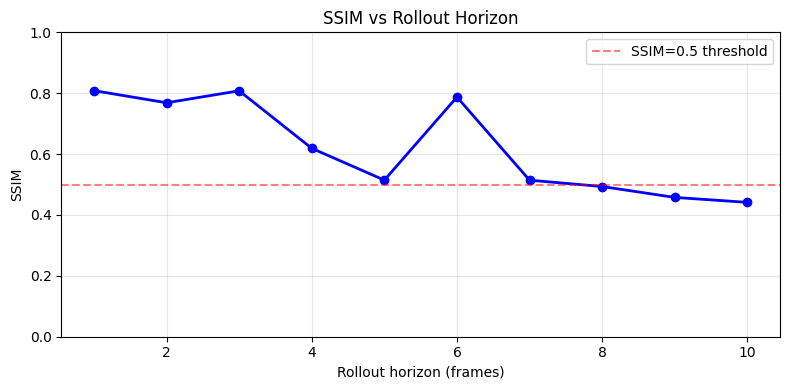

In [11]:
# Rollout: predict ROLLOUT_STEPS frames from a single seed frame
print(f"Rollout: {ROLLOUT_STEPS} frames from seed frame")
print("(GT disponible seulement pour les {BPTT_STEPS} premiers)")

# Use longer sequences for rollout evaluation
rollout_dataset = MovingMNISTDataset(npy_file=DATA_PATH, bptt_steps=min(ROLLOUT_STEPS, 19))
rollout_loader = DataLoader(rollout_dataset, batch_size=8, shuffle=True)
rollout_batch = next(iter(rollout_loader))

ssim_per_step = show_rollout(model, rollout_batch, n_steps=ROLLOUT_STEPS)

if ssim_per_step:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, len(ssim_per_step)+1), ssim_per_step, 'b-o', linewidth=2, markersize=6)
    ax.set_xlabel('Rollout horizon (frames)')
    ax.set_ylabel('SSIM')
    ax.set_title('SSIM vs Rollout Horizon')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='SSIM=0.5 threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 10. Feature space analysis

Collected features: torch.Size([320, 128, 16, 16])


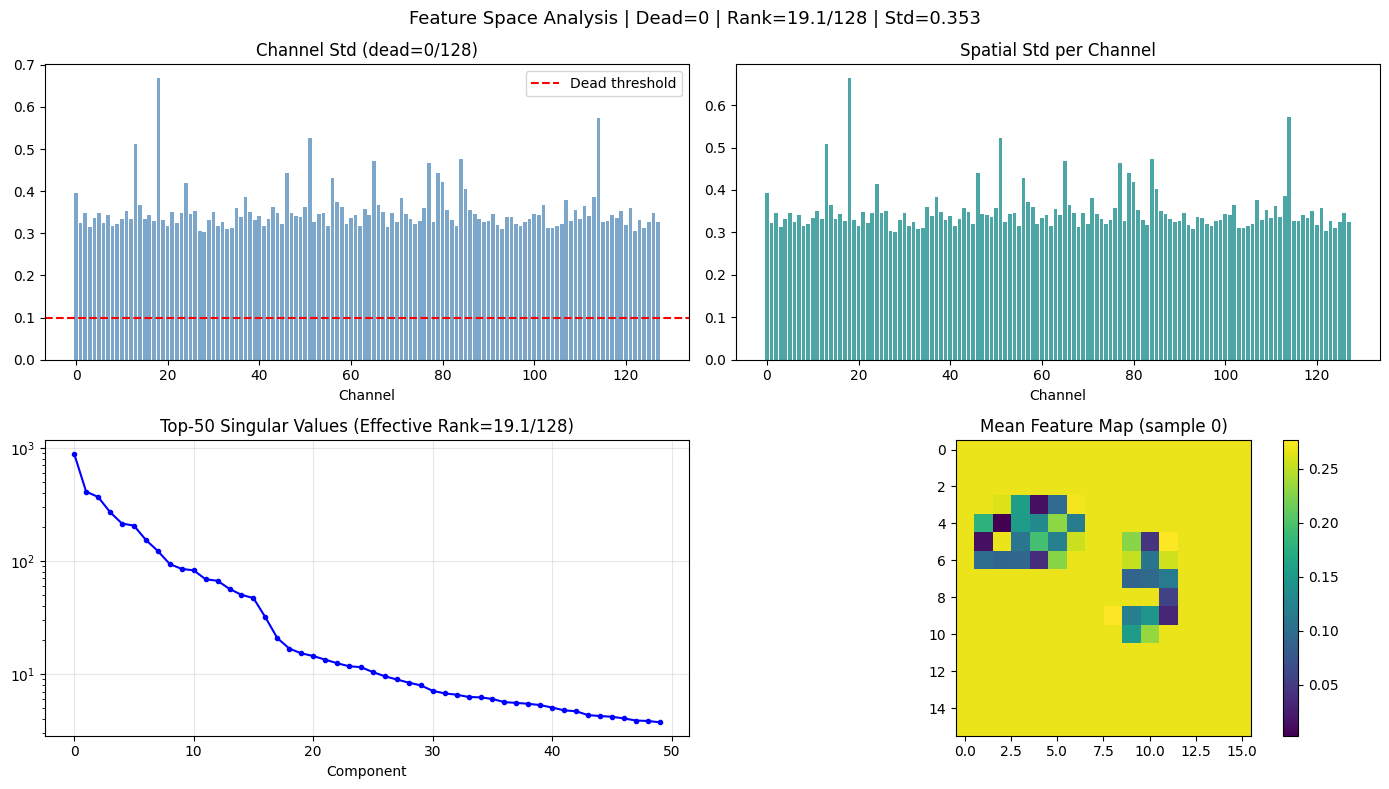


Feature health: HEALTHY
  Dead dims: 0/128
  Effective rank: 19.1/128 (14.9%)
  Mean channel std: 0.3526
  Mean spatial std: 0.3500


In [13]:
model.eval()

# Collect features from multiple batches
all_features = []
n_analysis_batches = 20

with torch.no_grad():
    for i, batch in enumerate(train_loader):
        if i >= n_analysis_batches:
            break
        batch = batch.to(device)
        enc = model.encode(batch[:, 0])
        feats = enc["features"]  # (B, C, H, W)
        all_features.append(feats.cpu())

all_features = torch.cat(all_features, dim=0)  # (N, C, H, W)
print(f"Collected features: {all_features.shape}")

# Channel statistics
channel_std = all_features.std(dim=(0, 2, 3))  # (C,)
channel_mean = all_features.mean(dim=(0, 2, 3))  # (C,)
spatial_std = all_features.std(dim=(2, 3)).mean(dim=0)  # (C,)

dead_dims = (channel_std < 0.1).sum().item()

# Effective rank
flat = all_features.permute(1, 0, 2, 3).reshape(D_MODEL, -1)  # (C, N*H*W)
centered = flat - flat.mean(dim=1, keepdim=True)
s = torch.linalg.svdvals(centered)
p = s / s.sum()
entropy = -(p * torch.log(p + 1e-10)).sum().item()
effective_rank = math.exp(entropy)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Channel std distribution
axes[0, 0].bar(range(D_MODEL), channel_std.numpy(), color='steelblue', alpha=0.7)
axes[0, 0].axhline(y=0.1, color='red', linestyle='--', label='Dead threshold')
axes[0, 0].set_title(f'Channel Std (dead={dead_dims}/{D_MODEL})')
axes[0, 0].set_xlabel('Channel')
axes[0, 0].legend()

# Spatial std (are features spatially structured?)
axes[0, 1].bar(range(D_MODEL), spatial_std.numpy(), color='teal', alpha=0.7)
axes[0, 1].set_title('Spatial Std per Channel')
axes[0, 1].set_xlabel('Channel')

# Singular values (rank)
axes[1, 0].plot(s.numpy()[:50], 'b-o', markersize=3)
axes[1, 0].set_title(f'Top-50 Singular Values (Effective Rank={effective_rank:.1f}/{D_MODEL})')
axes[1, 0].set_xlabel('Component')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Feature heatmap (mean over channels for first sample)
feat_map = all_features[0].mean(dim=0).numpy()  # (H, W)
im = axes[1, 1].imshow(feat_map, cmap='viridis')
plt.colorbar(im, ax=axes[1, 1])
axes[1, 1].set_title('Mean Feature Map (sample 0)')

fig.suptitle(
    f'Feature Space Analysis | '
    f'Dead={dead_dims} | Rank={effective_rank:.1f}/{D_MODEL} | '
    f'Std={channel_std.mean():.3f}',
    fontsize=13
)
plt.tight_layout()
save_dir = os.path.join('..', 'paper', 'figures')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'fig_feature_analysis_pixel.pdf'), bbox_inches='tight', dpi=150)
plt.savefig(os.path.join(save_dir, 'fig_feature_analysis_pixel.png'), bbox_inches='tight', dpi=150)
plt.show()

model.train()
print(f"\nFeature health: {'HEALTHY' if dead_dims < 5 and effective_rank > 10 else 'WARNING'}")
print(f"  Dead dims: {dead_dims}/{D_MODEL}")
print(f"  Effective rank: {effective_rank:.1f}/{D_MODEL} ({effective_rank/D_MODEL:.1%})")
print(f"  Mean channel std: {channel_std.mean():.4f}")
print(f"  Mean spatial std: {spatial_std.mean():.4f}")

## 11. Summary

In [15]:
print("=" * 60)
print("MOVING MNIST TRAINING SUMMARY")
print("=" * 60)
print(f"Model: FluidWorld PDE (d_model={D_MODEL}, {params['total']:,} params)")
print(f"Training: {EPOCHS} epochs, {global_step} steps total")
elapsed_total_summary = globals().get('elapsed_total', history.get('elapsed_total_sec'))
if elapsed_total_summary is None and 't_start' in globals():
    elapsed_total_summary = time.time() - t_start
if elapsed_total_summary is not None:
    print(f"Duration: {elapsed_total_summary/60:.1f} min")
else:
    print("Duration: unavailable (run training cell first)")
print()
print(f"Final total loss: {history['total_loss'][-1]:.4f}")
print(f"Final recon loss: {history['recon_loss'][-1]:.4f}")
print(f"Final pred loss:  {history['pred_loss'][-1]:.4f}")
if history.get('edge_loss'):
    print(f"Final edge loss:  {history['edge_loss'][-1]:.4f}")
if history.get('freq_loss'):
    print(f"Final freq loss:  {history['freq_loss'][-1]:.4f}")
print()
if history['ssim_recon']:
    print(f"Last SSIM recon: {history['ssim_recon'][-1]:.3f}")
    print(f"Last SSIM pred:  {history['ssim_pred'][-1]:.3f}")
print()
print(f"Feature std: {history['feature_std'][-1]:.4f}")
print(f"Feature health: {'HEALTHY' if history['feature_std'][-1] > 0.1 else 'COLLAPSED'}")
print()
if ssim_per_step:
    print(f"Rollout SSIM ({len(ssim_per_step)} steps): {[f'{s:.3f}' for s in ssim_per_step]}")
    horizon_05 = next((i+1 for i, s in enumerate(ssim_per_step) if s < 0.5), len(ssim_per_step))
    print(f"Rollout horizon (SSIM>0.5): {horizon_05} frames")
print()
print(f"Checkpoint: {ckpt_dir / f'model_epoch_{EPOCHS}.pt'}")
print("=" * 60)

MOVING MNIST TRAINING SUMMARY
Model: FluidWorld PDE (d_model=128, 862,093 params)
Training: 100 epochs, 15056 steps total
Duration: 78.5 min

Final total loss: 0.1104
Final recon loss: 0.0316
Final pred loss:  0.0788
Final edge loss:  0.8080
Final freq loss:  52.8285

Last SSIM recon: 0.990
Last SSIM pred:  0.800

Feature std: 0.2368
Feature health: HEALTHY

Rollout SSIM (10 steps): ['0.808', '0.769', '0.808', '0.619', '0.514', '0.787', '0.514', '0.493', '0.458', '0.441']
Rollout horizon (SSIM>0.5): 8 frames

Checkpoint: C:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld\checkpoints\moving_mnist\model_epoch_100.pt
